In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from imblearn.combine import import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
app = pd.read_csv(r"C:\Users\SHAIK AHMED SHARIFF\Downloads\archive (1)\application_record.csv")
credit = pd.read_csv(r"C:\Users\SHAIK AHMED SHARIFF\Downloads\archive (1)\credit_record.csv")

In [3]:
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Number of people working status :
OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64


C:\Users\SHAIK AHMED SHARIFF\AppData\Local\Temp\ipykernel_24828\1064149118.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='OCCUPATION_TYPE', data=app, palette = 'Set2')


<Axes: xlabel='OCCUPATION_TYPE', ylabel='count'>

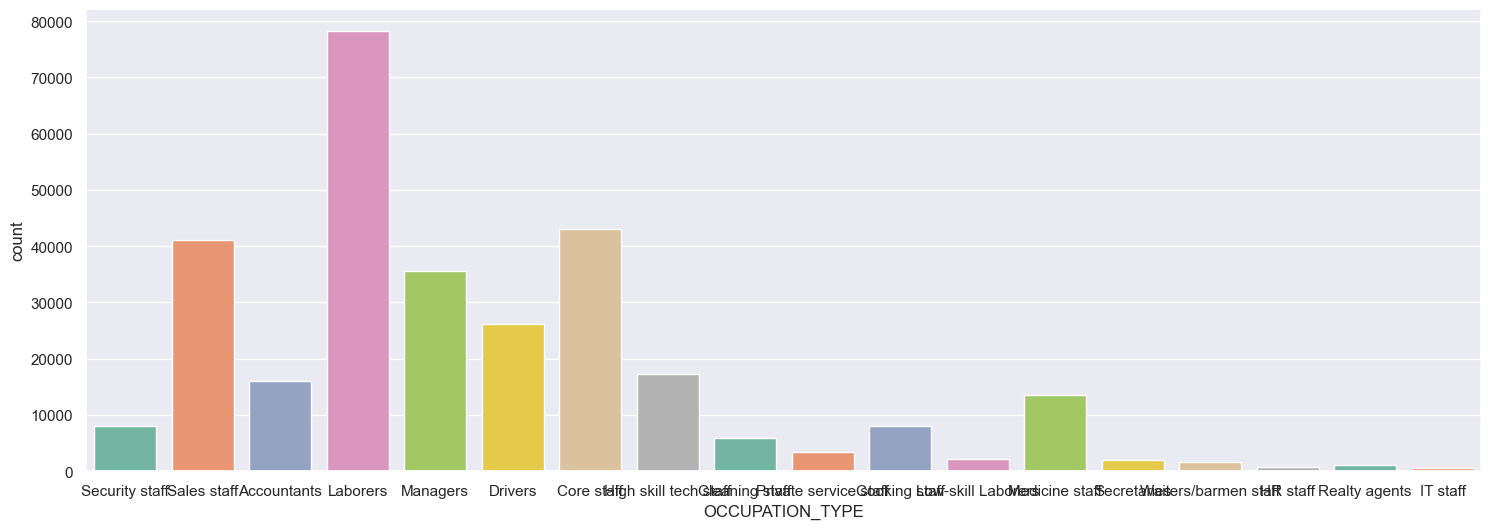

In [4]:
print("Number of people working status :")
print(app['OCCUPATION_TYPE'].value_counts())
sns.set(rc = {'figure.figsize':(18,6)})
sns.countplot(x='OCCUPATION_TYPE', data=app, palette = 'Set2')

<Axes: >

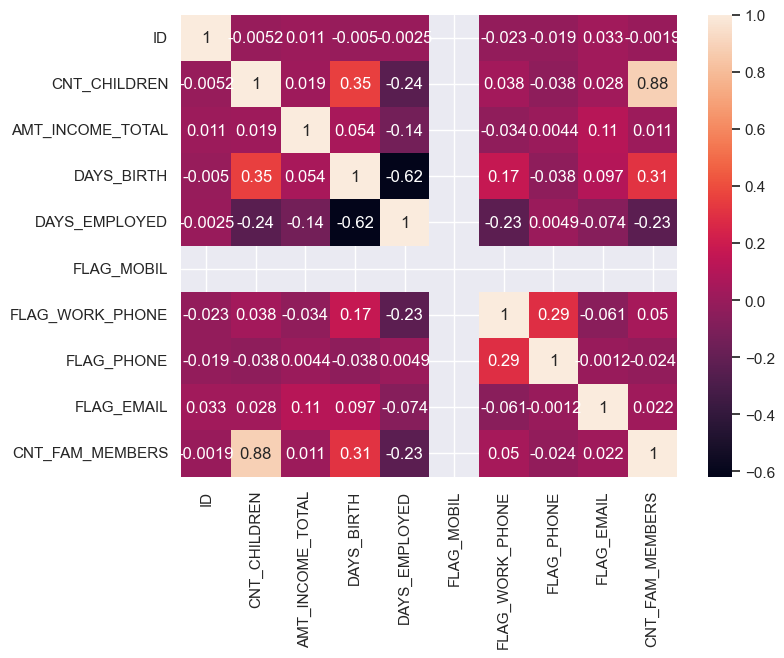

In [6]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(app.corr(numeric_only=True), annot=True)

In [7]:
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [9]:
# dropping duplicate rows
app.drop_duplicates(subset = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
    'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
    'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
    'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'], keep = 'first', inplace = True)

In [10]:
app.isnull().mean()

ID                     0.000000
CODE_GENDER            0.000000
FLAG_OWN_CAR           0.000000
FLAG_OWN_REALTY        0.000000
CNT_CHILDREN           0.000000
AMT_INCOME_TOTAL       0.000000
NAME_INCOME_TYPE       0.000000
NAME_EDUCATION_TYPE    0.000000
NAME_FAMILY_STATUS     0.000000
NAME_HOUSING_TYPE      0.000000
DAYS_BIRTH             0.000000
DAYS_EMPLOYED          0.000000
FLAG_MOBIL             0.000000
FLAG_WORK_PHONE        0.000000
FLAG_PHONE             0.000000
FLAG_EMAIL             0.000000
OCCUPATION_TYPE        0.305012
CNT_FAM_MEMBERS        0.000000
dtype: float64

In [13]:
import pandas as pd
import numpy as np

def data_cleaning(application_df, credit_df):

    # -----------------------------
    # 1. Create Family Dependency Feature
    # -----------------------------
    application_df['Family_Size'] = (
        application_df['CNT_FAM_MEMBERS'] +
        application_df['CNT_CHILDREN']
    )

    # -----------------------------
    # 2. Remove Unnecessary Columns
    # -----------------------------
    cols_to_drop = ['OCCUPATION_TYPE']   # Add more columns if required

    application_df.drop(
        columns=[col for col in cols_to_drop if col in application_df.columns],
        inplace=True,
        errors='ignore'
    )

    # -----------------------------
    # 3. Convert Negative Days to Positive
    # -----------------------------
    application_df['DAYS_BIRTH'] = application_df['DAYS_BIRTH'].abs()
    application_df['DAYS_EMPLOYED'] = application_df['DAYS_EMPLOYED'].abs()

    # -----------------------------
    # 4. Map Categorical Variables
    # -----------------------------
    housing_map = {
        'House / apartment': 0,
        'With parents': 1,
        'Municipal apartment': 2,
        'Rented apartment': 3,
        'Office apartment': 4,
        'Co-op apartment': 5
    }

    income_map = {
        'Working': 0,
        'Commercial associate': 1,
        'Pensioner': 2,
        'State servant': 3,
        'Student': 4
    }

    education_map = {
        'Lower secondary': 0,
        'Secondary / secondary special': 1,
        'Incomplete higher': 2,
        'Higher education': 3,
        'Academic degree': 4
    }

    family_map = {
        'Single / not married': 0,
        'Married': 1,
        'Civil marriage': 2,
        'Separated': 3,
        'Widow': 4
    }

    application_df['NAME_HOUSING_TYPE'] = \
        application_df['NAME_HOUSING_TYPE'].map(housing_map)

    application_df['NAME_INCOME_TYPE'] = \
        application_df['NAME_INCOME_TYPE'].map(income_map)

    application_df['NAME_EDUCATION_TYPE'] = \
        application_df['NAME_EDUCATION_TYPE'].map(education_map)

    application_df['NAME_FAMILY_STATUS'] = \
        application_df['NAME_FAMILY_STATUS'].map(family_map)

    # -----------------------------
    # 5. Process Credit Records
    # -----------------------------
    credit_summary = credit_df.groupby('ID').agg(
        open_month=('MONTHS_BALANCE', 'min'),
        end_month=('MONTHS_BALANCE', 'max')
    ).reset_index()

    # Credit activity window
    credit_summary['window'] = (
        credit_summary['end_month'] -
        credit_summary['open_month']
    )

    # Payment behaviour
    status_df = credit_df.groupby('ID')['STATUS'].apply(list).reset_index()

    def payment_status(status_list):
        if any(status in ['1', '2', '3', '4', '5'] for status in status_list):
            return 1      # Delayed payment
        elif '0' in status_list:
            return 0      # Timely payment
        else:
            return -1     # No loan record

    status_df['payment_behavior'] = \
        status_df['STATUS'].apply(payment_status)

    # Merge credit features
    credit_summary = credit_summary.merge(
        status_df[['ID', 'payment_behavior']],
        on='ID',
        how='left'
    )

    return application_df, credit_summary

In [16]:
# Convert STATUS column into binary labels

def convert_status(status_list):

    # Good repayment behavior → Approved (0)
    if all(status in ['C', 'X', '0'] for status in status_list):
        return 0      # Approved

    # Poor credit behavior → Not Approved (1)
    elif any(status in ['1', '2', '3', '4', '5'] for status in status_list):
        return 1      # Not Approved

    return 0


# Group credit records by applicant ID
credit_grouped = credit.groupby('ID')['STATUS'].apply(list).reset_index()

# Create binary target column
credit_grouped['target'] = credit_grouped['STATUS'].apply(convert_status)

# Keep only required columns
credit_grouped = credit_grouped[['ID', 'target']]

# Merge applicant details with credit history
final_df = pd.merge(app,
                    credit_grouped,
                    on='ID',
                    how='inner')

# Display output similar to your screenshot
display(
    final_df.head().T.style.format(
        lambda x: f"{x:.6f}" if isinstance(x, (int, float, np.number)) else str(x)
    )
)

,0,1,2,3,4
ID,5008804.000000,5008806.000000,5008808.000000,5008812.000000,5008815.000000
CODE_GENDER,M,M,F,F,M
FLAG_OWN_CAR,Y,Y,N,N,Y
FLAG_OWN_REALTY,Y,Y,Y,Y,Y
CNT_CHILDREN,0.000000,0.000000,0.000000,0.000000,0.000000
AMT_INCOME_TOTAL,427500.000000,112500.000000,270000.000000,283500.000000,270000.000000
NAME_INCOME_TYPE,Working,Working,Commercial associate,Pensioner,Working
NAME_EDUCATION_TYPE,Higher education,Secondary / secondary special,Secondary / secondary special,Higher education,Higher education
NAME_FAMILY_STATUS,Civil marriage,Married,Single / not married,Separated,Married
NAME_HOUSING_TYPE,Rented apartment,House / apartment,House / apartment,House / apartment,House / apartment


In [ ]:
from sklearn.preprocessing import LabelEncoder

cg = LabelEncoder()
oc = LabelEncoder()
own_r = LabelEncoder()
it = LabelEncoder()
et = LabelEncoder()
fs = LabelEncoder()
ht = LabelEncoder()

final_df['CODE_GENDER'] = cg.fit_transform(final_df['CODE_GENDER'])
final_df['FLAG_OWN_CAR'] = oc.fit_transform(final_df['FLAG_OWN_CAR'])
final_df['FLAG_OWN_REALTY'] = own_r.fit_transform(final_df['FLAG_OWN_REALTY'])
final_df['NAME_INCOME_TYPE'] = it.fit_transform(final_df['NAME_INCOME_TYPE'])
final_df['NAME_EDUCATION_TYPE'] = et.fit_transform(final_df['NAME_EDUCATION_TYPE'])
final_df['NAME_FAMILY_STATUS'] = fs.fit_transform(final_df['NAME_FAMILY_STATUS'])
final_df['NAME_HOUSING_TYPE'] = ht.fit_transform(final_df['NAME_HOUSING_TYPE'])